```2026/09/10 09:48```

# Optimization characterization for `CAXSim`

This notebook aims to study and guide the application of optimization algorithms
to the Carcará-X beamline simulation. Aside from the optimization method, there 
are multiple aspects of the optimization procedure that require careful consideration:

- A. Objective function choice

- B. Measurement procedure

- C. Degrees of freedom / # of knobs

- D. Optimization method parameters

## A. objective functions

### 1. Simple size/intensity ratio

A function of the form: $f_1(\sigma_x, \sigma_y, I) = \dfrac{\sigma_x \sigma_y}{I}$

This form is very simple, but it has a few drawbacks:

- Intensity is hard to define/compare between simulation and real beamline;
- The two sigmas have different effective wheights, as the beam is usually 
stretched horizontally.

### 2. Normalized pure geometric

A function of the form: $f_2(\sigma_x, \sigma_y) = \dfrac{\sigma_x}{ \sigma_x^0} 
                                                    + \dfrac{\sigma_x}{ \sigma_x^0}$

where the normalization factors $\sigma_{x/y}^0$ are the values given by the 
Sirius model for the electron beam sizes at the site of CAX.

This function balances out the weight of the two sigmas but doesn't take intensity
into account.

### 3. Pure intensity

A function of the form: $f_3(I) = -\dfrac{I}{I_0}$

where $I_0$ is a normalization term for intensity, to be identified.

In theory, if intensity is well defined and the whole parameter space is searched,
the optimizer should find the tightest beam where intensity is maximized.

### 4. Geometric + intensity

A function of the form: $f_4(\sigma_x, \sigma_y, I) = f_2(\sigma_x, \sigma_y)
                                                    + f_3(I)$

This further restricts the objective, but takes into account both geometrical and
intensity features.

### 5. Astigmatism

A function of the form $f_5(d) = \dfrac{|d|}{\Delta}$

where $d$ represents the difference in foci positions $d = f_y - f_x$. The 
normalization parameter $\Delta$ should be of the order of magnitude of the 
variations in astigmatism.

The drawback in this case is the fact that astigmatism acquisition is slow and 
expensive since it relies on a sweep of the DVF $z$ position. On the beamline
it appears that the DVF's rails do not extend far enough to really capture the 
positions of both foci, and as such, astigmatism acquisition strategies are also
important to consider.

### 6. Geometric + astigmatism / All

Finally, we combine either $f_2$, $f_3$ and $f_4$ with $f_5$. 

## B. Acquisition Method (DVF placement)

### 1. DVF at fixed original position ($z=0$)

Performing acquisitions with the DVF device's position fixed at $z=0$ (in relation
to it's own coordinate system) is the most natural acquisition method in the real
beamline. However, as the beam foci vary with incidence angle, optimizing a particular
objective function with observable values taken at $z=0$ does not necessarily produce
an optimal beam image at the focus position.

The advantage of this type of acquisition is how cheap it is, not prompting us to
move the DVF at all.

### 2. DVF at focus ($z = \bar f$)

Defining a focus position is tricky in itself as the M1 toroidal mirror introduces 
an astigmatism effect due to its two different radii of curvature. An option is 
to define $\bar f \equiv (f_x +f_y)/2$ as the *avarege focus* of the system. An 
optimization that matches the foci will reduce the astigmatism and determine the 
true focus as $\bar f$ itself.

The natural advantage of this methos is the fact that it takes into account the
foci matching objective and will probably optimize faster as multiple observables
will be optimal in the true matched focus of the optical system.

The clear disadvantage is the fact that one needs to know $f_x$ and $f_y$ to 
compute $\bar f$, which requires a caustic scan and is inherently expensive and 
potentially noisy (or sensitive to motor position uncertainties). If we're able 
to obtain good results using the previous acquisiton method the optimization will
be greatly accelerated.

---

First, we'll set up methods to characterize the different objective functions.
Starting with just two knobs, the mirror's translation in x and the y rotation
we'll first measure sigmas, intensity and astigmatism for every combination of 
TX and RY. We'll also save acquisitions taken with the DVF placed exactly at the
midpoint of the foci $\bar f$.



In [1]:
# Imports

import matplotlib.pyplot as plt

# from Shadow import histo
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from shadowpy.si_beamlines import CAXSim
from shadowpy.utils import save_image, Image


def add_minimum_band_legend(ax, x, y, values, fraction=0.005, legend=False):
    """Highlight and label the region within `fraction` of the minimum."""
    minimum = np.nanmin(values)
    level = minimum + fraction * np.ptp(values)

    ax.contourf(
        x, y, values,
        levels=[minimum, level],
        colors=["red"],
        alpha=0.3,
    )

    proxy = Patch(
        facecolor="red",
        alpha=0.3,
        label=f"{fraction:.1%} above minimum",
    )

    handles, labels = ax.get_legend_handles_labels()
    if legend:
        ax.legend(
            handles=[*handles, proxy],
            loc="lower right",
            fontsize=10,
            frameon=True,
            facecolor="white",
            edgecolor="black",
        )

No module named 'xraylib'


In [2]:
def _astigmatism_acquisition(cax: CAXSim):

    # Initial search

    low_lim = -1000
    hgh_lim =  1000

    done = False

    while not done:
        distances, fwhm_x, fwhm_y = \
            cax.dvf_B1.parallel_caustic(cax.dvf_B1.beam.duplicate(),
                                        s_range=(low_lim, hgh_lim),
                                        n_points=50, 
                                        max_workers=10)
        # prior focal lengths
        fx = distances[np.nanargmin(fwhm_x)]
        fy = distances[np.nanargmin(fwhm_y)]

        print(fx, fy)

        done = True

        # check if the search was enought otherwise repeat
        if low_lim in [fx, fy]:
            low_lim -= 100
            done = False

        if hgh_lim in [fx, fy]:
            hgh_lim += 100
            done = False

    # Finer search
    distances, fwhm_x, fwhm_y = \
    cax.dvf_B1.parallel_caustic(cax.dvf_B1.beam.duplicate(),
                                s_range=(np.min([fx, fy])-50, np.max([fx, fy])+50),
                                n_points=100, 
                                max_workers=10)

    # actual focal lengths
    fx = distances[np.nanargmin(fwhm_x)]
    fy = distances[np.nanargmin(fwhm_y)]
    print(fx, fy)

    f = np.mean([fx, fy])
    retr_beam = cax.dvf_B1.beam.duplicate()
    retr_beam.retrace(f)
    img = save_image(cax.dvf_B1, retr_beam)
    astig = fy - fx

    return distances, fwhm_x, fwhm_y, fx, fy, f, astig, img 


In [3]:
def display_image(image: Image):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    bin_h_centers = (image.bin_h_edges[1:]+image.bin_h_edges[:-1])/2
    bin_v_centers = (image.bin_v_edges[1:]+image.bin_v_edges[:-1])/2

    hist = image.histogram

    p = ax.pcolormesh(image.bin_h_edges, image.bin_v_edges, hist.T)
    fig.colorbar(p, ax=ax, label="count")

    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')

    return fig, ax

In [4]:
cax = CAXSim()

 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
Traced through element 2: DVF_A1
 Exit from IMREF
 Call 

In [34]:
cax.mirror.ty = 1

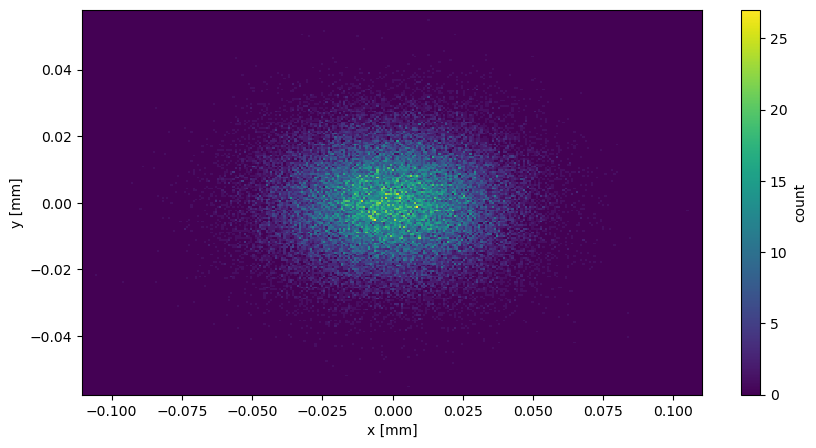

In [5]:
fig, ax = display_image(cax.dvf_B1.image)


First, we need to define intensity in a precise way. As we are using raytracing simulation, the final
image is a histogram where each bin contains a certain ammount of rays. A way to define intensity is
to count how many rays lie inside a certain area of the beam, that should be proportional to energy 
divided by area.

In [6]:
x_bin_centers = cax.dvf_B1.image.bin_h_centers
y_bin_centers = cax.dvf_B1.image.bin_v_centers
X_bins, Y_bins = np.meshgrid(x_bin_centers, y_bin_centers)

sigma_x = cax.dvf_B1.image.sigma_h
sigma_y = cax.dvf_B1.image.sigma_v

cx = cax.dvf_B1.image.centroid_h
cy = cax.dvf_B1.image.centroid_v

In [7]:
R = ((X_bins-cx)**2/(2*sigma_x)**2 + (Y_bins-cy)**2/(2*sigma_y)**2)

In [8]:
mask = R <= 1
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [9]:
mask.shape

(210, 280)

In [11]:
img = cax.dvf_B1.image.histogram.T
masked_img = np.where(mask, img, 0)

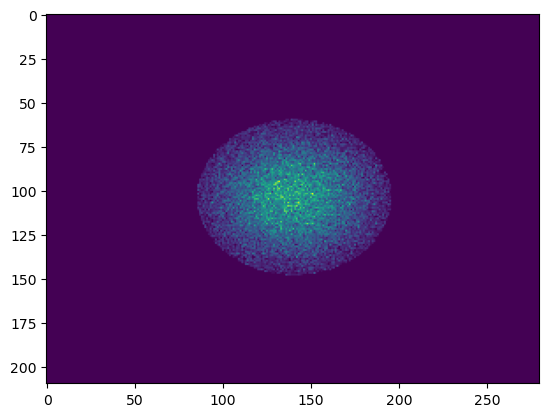

In [12]:
plt.imshow(masked_img)

In [13]:
I = int(np.sum(masked_img))

# Use half of the cast rays to define the normalization, as part of the rays are
# naturally lost during the tracing. This also adjusts the artio to more significant
# values, aiding in the definition of the intensity objective. 
I0 = 0.5*cax.total_rays

# I0 = np.sum(cax.dvf_B1.image.img) 
# ^ This is a crappy definition of I0, since in a bigaussian distribution the 
# area enclosed by the 2σ ellipse is always 86.47 % of total distribution, so the 
# I/I0 ratio will always be ≈ 0.8647.

print(f"Total rays: {I0}, flux of rays: {I}, I/I0: {I/I0:.3f}")

Total rays: 50000.0, flux of rays: 51305, I/I0: 1.026


With this we can define intensity given an image. Let's formalize in a function:

In [16]:
def intensity(image: Image):

    x_bin_centers = image.bin_h_centers
    y_bin_centers = image.bin_v_centers
    X_bins, Y_bins = np.meshgrid(x_bin_centers, y_bin_centers)

    sigma_x = image.sigma_h
    sigma_y = image.sigma_v

    cx = image.centroid_h
    cy = image.centroid_v

    R = ((X_bins-cx)**2/(2*sigma_x)**2 + (Y_bins-cy)**2/(2*sigma_y)**2)

    masked_img = np.where(R <= 1, image.histogram.T, 0)

    I = np.sum(masked_img)

    return I

In [17]:
intensity(cax.dvf_B1.image)

51305.00000000003

The acquisition was made using a fine grid of TX and RY values and stored as a csv. Interpolation was
used to acquire some intermediate values which were not stored in the first run. We will import the
data into pandas dataframes here:

⚠️ **THE DATA WAS SAVED USING ANALYSIS METHODS DIFFERENT FROM THE CURRENTLY IMPLEMENTED IN `shadowpy`,**
**DIFFERENCES IN THE VALUES DISCUSSED IN THE TEXT AND OBTAINED BY RUNNING THIS NOTEBOOK NOW ARE EXPECTED**,
**THE OPTIMIZER MAY ALSO UNDERPERFORM, BUT DIFFERENCES SHOULD BE MARGINAL AND THE VALIDITY OF THE ANALYSIS**
**HERE PRESENTED SHOULD HOLD.**

In [19]:
df_at_dvf = pd.read_csv("knobspace_data/df_at_dvf_fine_interpolated.csv")
df_at_focus = pd.read_csv("knobspace_data/df_at_focus_fine_interpolated.csv")

In [20]:
df_at_dvf

,TX,RY,Intensity,sigma_x,sigma_y,astigmatism
0,-4.00,-0.1,11991.0,0.019838,0.022390,-335.168007
1,-3.95,-0.1,13289.0,0.019857,0.022112,-335.611214
2,-3.90,-0.1,14587.0,0.019877,0.021835,-336.054422
3,-3.85,-0.1,15907.5,0.019898,0.021573,-342.517007
4,-3.80,-0.1,17228.0,0.019920,0.021311,-348.979592
...,...,...,...,...,...,...
25916,3.80,0.1,17598.0,0.022322,0.013566,556.132756
25917,3.85,0.1,16283.5,0.022085,0.013730,562.914863
25918,3.90,0.1,14969.0,0.021848,0.013894,569.696970
25919,3.95,0.1,13667.5,0.021717,0.014030,594.207380


Extracting the values from the dataframes

In [22]:
# N = len(df_at_dvf)
# n = np.sqrt(N)
n = 161
tx_vals = np.asarray(df_at_dvf['TX']).reshape(int(n), int(n))
ry_vals = np.asarray(df_at_dvf['RY']).reshape(int(n), int(n))

intensity_vals = np.asarray(df_at_dvf['Intensity']).reshape(int(n), int(n))
sigmax_vals = np.asarray(df_at_dvf['sigma_x']).reshape(int(n), int(n))
sigmay_vals = np.asarray(df_at_dvf['sigma_y']).reshape(int(n), int(n))

astig_vals = np.asarray(df_at_dvf['astigmatism']).reshape(int(n), int(n))

TX, RY = np.meshgrid(tx_vals, ry_vals)

Let's have a look at the observables individually, performing the necessary sign 
inversions, applying `abs` for the astigmatism and changing sigma's units to $\mu$ m

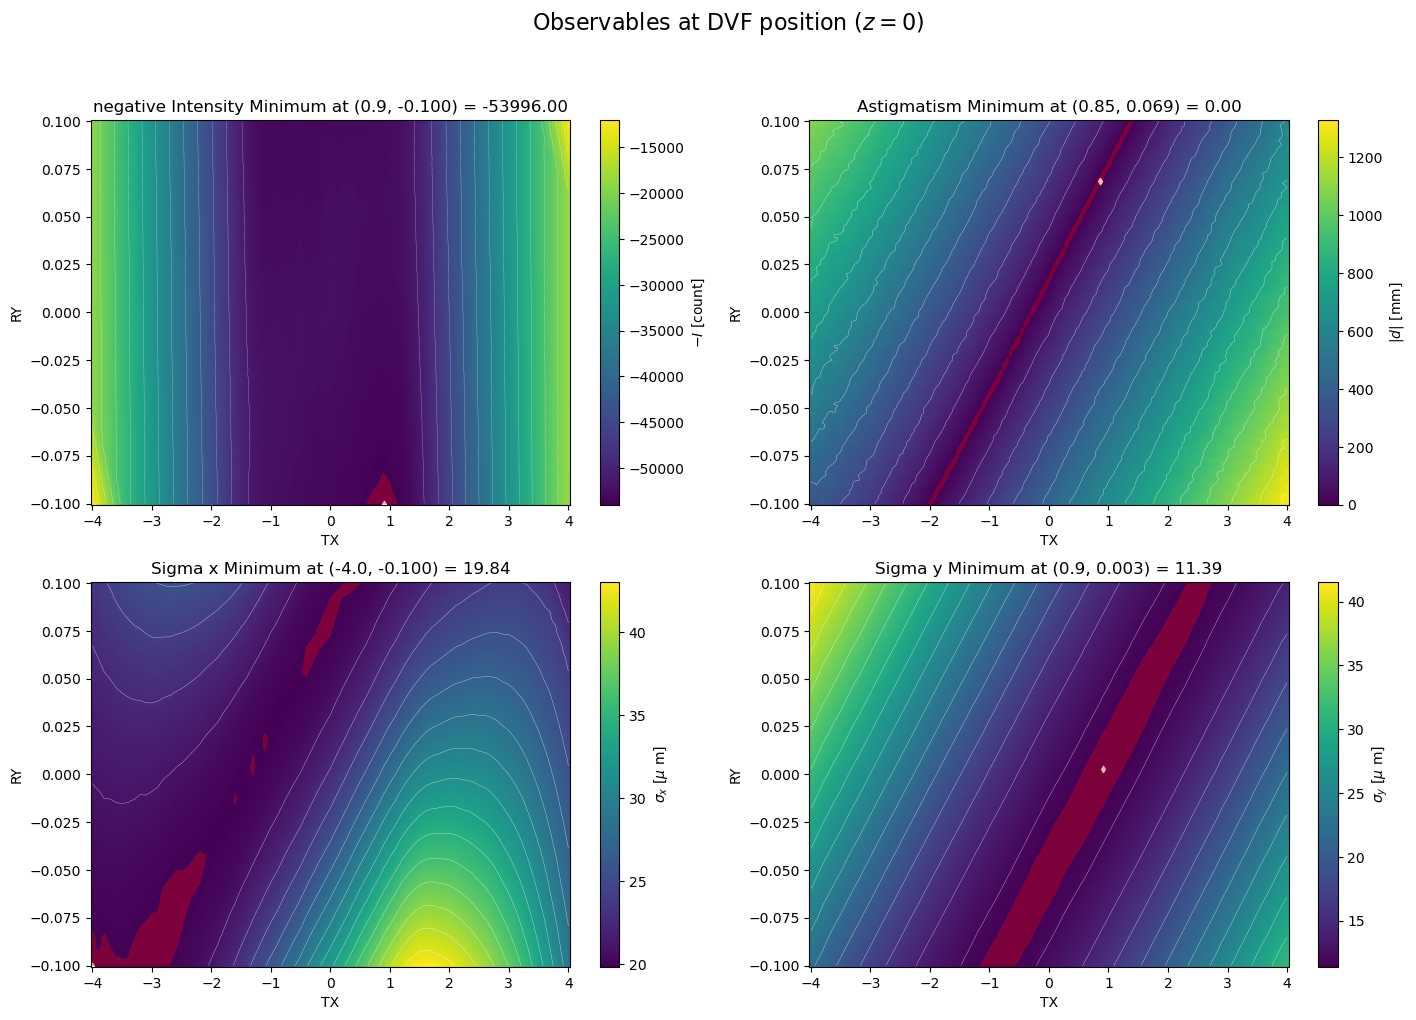

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(17, 11))

axs = axs.flatten()

fig.suptitle("Observables at DVF position ($z = 0$)", fontsize=16)


obs = [-intensity_vals, np.abs(astig_vals), 1000*sigmax_vals, 1000*sigmay_vals]
obs_lbl = ["$-I$ [count]", "$|d|$ [mm]", "$\\sigma_x$ [$\\mu$ m]", "$\\sigma_y$ [$\\mu$ m]"]
obs_names = ["negative Intensity", "Astigmatism", "Sigma x", "Sigma y"]

for i in range(4):

    p = axs[i].pcolormesh(tx_vals, ry_vals, obs[i], shading='auto')
    argmin = np.unravel_index(obs[i].argmin(), obs[i].shape)

    tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

    axs[i].scatter(tx_min, ry_min, c='white', marker='d',s=10)
    axs[i].contour(
        tx_vals, ry_vals, obs[i],
        levels=15,
        colors="white",
        linewidths=0.2,
    )
    add_minimum_band_legend(axs[i], tx_vals, ry_vals, obs[i], legend=False)
    axs[i].set_xlabel("TX")
    axs[i].set_ylabel("RY")
    axs[i].set_title(obs_names[i] + 
                     f" Minimum at ({round(tx_min, 2)}, {ry_min:.3f}) = {obs[i][argmin]:.2f}")
    fig.colorbar(p, ax=axs[i], label=obs_lbl[i])



Let's now look at the proposed objective functions. The normalization constants will be as follow:

$I_0 \equiv $ half of `total_rays = 50 000`;

$\Delta = 500 ~mm$, the total reach of CAX's DVF z translation;

$\sigma_x^0 = 19.9 ~\mu m$;

$\sigma_y^0 = 11.5 ~\mu m$;

Before defining the functions, let's check the normalized observables:

In [24]:
I0 = 0.5*cax.total_rays
Delta = 500
sigmax_0 = 19.9
sigmay_0 = 11.5

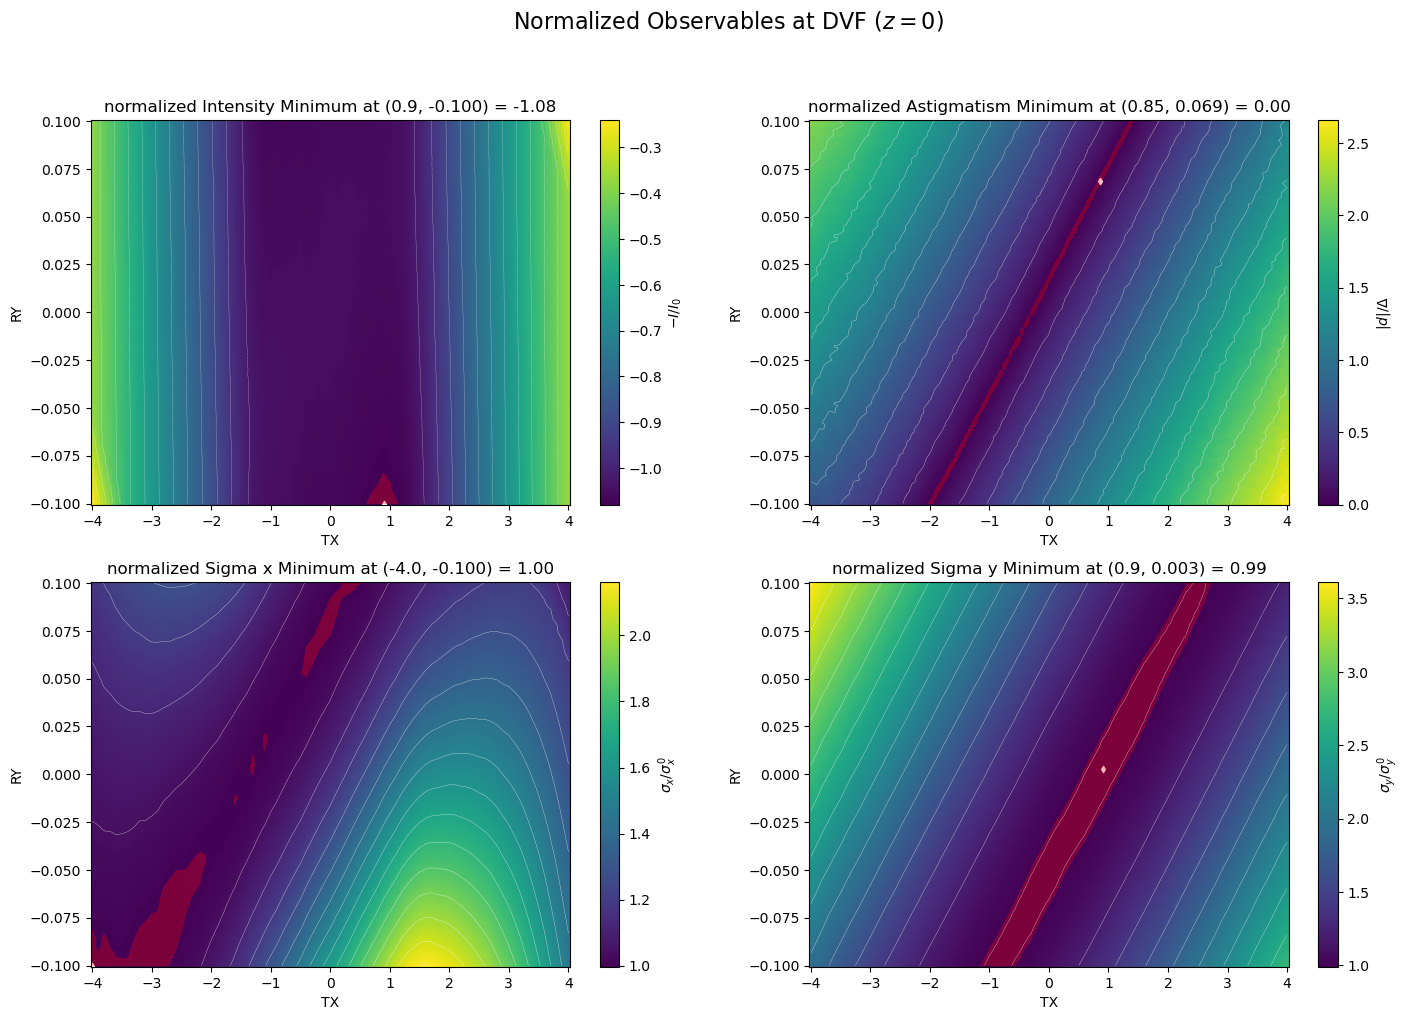

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(17, 11))

axs = axs.flatten()

fig.suptitle("Normalized Observables at DVF ($z=0$)", fontsize=16)


obs = [-intensity_vals/I0, np.abs(astig_vals)/Delta, 1000*sigmax_vals/sigmax_0, 1000*sigmay_vals/sigmay_0]
obs_lbl = ["$-I/I_0$", "$|d|/\\Delta$", "$\\sigma_x/\\sigma_x^0$", "$\\sigma_y/\\sigma_y^0$"]
obs_names = ["normalized Intensity", "normalized Astigmatism", "normalized Sigma x", "normalized Sigma y"]

for i in range(4):

    p = axs[i].pcolormesh(tx_vals, ry_vals, obs[i], shading='auto')
    argmin = np.unravel_index(obs[i].argmin(), obs[i].shape)

    tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

    axs[i].scatter(tx_min, ry_min, c='white', marker='d',s=10)
    axs[i].contour(tx_vals, ry_vals, obs[i], levels=15, colors='white', linewidths=0.2)

    add_minimum_band_legend(axs[i], tx_vals, ry_vals, obs[i], legend=False)
    
    axs[i].set_xlabel("TX")
    axs[i].set_ylabel("RY")
    axs[i].set_title(obs_names[i] + 
                     f" Minimum at ({round(tx_min, 2)}, {ry_min:.3f}) = {obs[i][argmin]:.2f}")
    fig.colorbar(p, ax=axs[i], label=obs_lbl[i])



Next we compute the 8 objectives discussed at the start of this section check their minima:

In [26]:
f1_dvf = (1000)**2*sigmax_vals*sigmay_vals/intensity_vals
f2_dvf = 1000*sigmax_vals/sigmax_0 + 1000*sigmay_vals/sigmay_0
f3_dvf = -intensity_vals/I0
f4_dvf = f2_dvf + f3_dvf
f5_dvf = np.abs(astig_vals)/Delta
f6_dvf = f2_dvf + f5_dvf
f7_dvf = f3_dvf + f5_dvf
f8_dvf = f4_dvf + f5_dvf

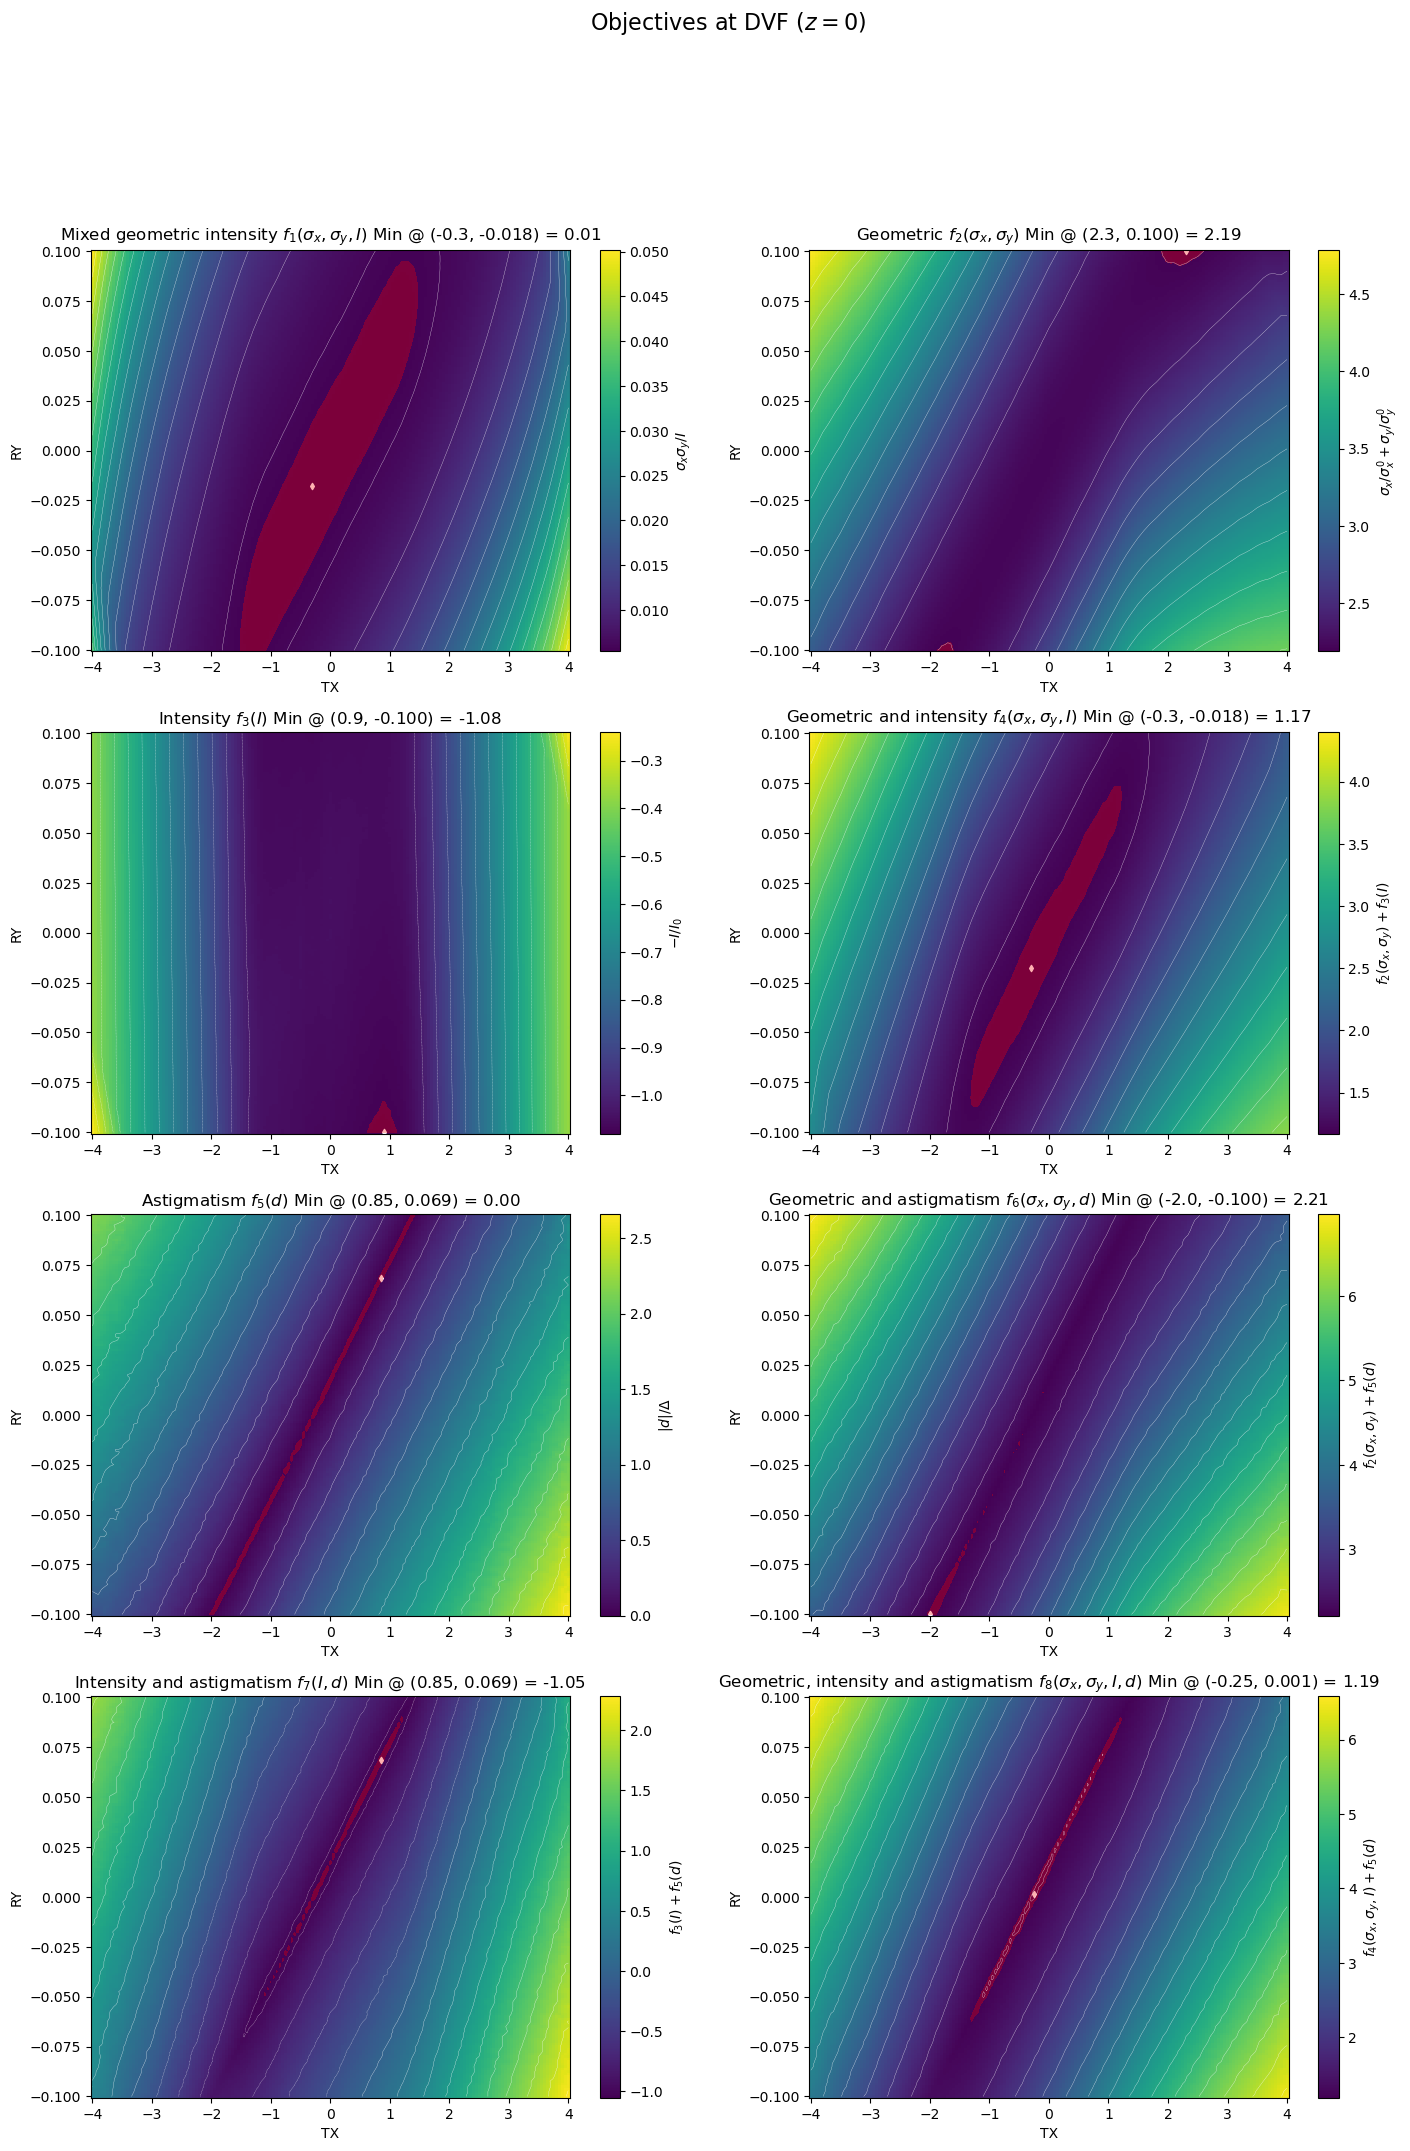

In [27]:
fig, axs = plt.subplots(4, 2, figsize=(17, 24))

axs = axs.flatten()

fig.suptitle("Objectives at DVF ($z=0$)", fontsize=16)

obs = [f1_dvf, f2_dvf, f3_dvf, f4_dvf, f5_dvf, f6_dvf, f7_dvf, f8_dvf]
obs_lbl = ["$\\sigma_x\\sigma_y/I$", 
           "$\\sigma_x/\\sigma_x^0 + \\sigma_y/\\sigma_y^0$", 
           "$-I/I_0$", 
           "$f_2(\\sigma_x, \\sigma_y) + f_3(I)$",
           "$|d|/\\Delta$",
           "$f_2(\\sigma_x, \\sigma_y) + f_5(d)$",
           "$f_3(I) + f_5(d)$",
           "$f_4(\\sigma_x, \\sigma_y, I) + f_5(d)$"]
obs_names = ["Mixed geometric intensity $f_1(\\sigma_x, \\sigma_y, I)$", 
             "Geometric $f_2(\\sigma_x, \\sigma_y)$", 
             "Intensity $f_3(I)$",
             "Geometric and intensity $f_4(\\sigma_x, \\sigma_y, I)$", 
             "Astigmatism $f_5(d)$",
             "Geometric and astigmatism $f_6(\\sigma_x, \\sigma_y, d)$",
             "Intensity and astigmatism $f_7(I, d)$",
             "Geometric, intensity and astigmatism $f_8(\\sigma_x, \\sigma_y, I, d)$"]

for i in range(8):

    p = axs[i].pcolormesh(tx_vals, ry_vals, obs[i], shading='auto')
    argmin = np.unravel_index(obs[i].argmin(), obs[i].shape)

    tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

    axs[i].scatter(tx_min, ry_min, c='white', marker='d',s=10)
    axs[i].contour(tx_vals, ry_vals, obs[i], levels=15, colors='white', linewidths=0.2)

    add_minimum_band_legend(axs[i], tx_vals, ry_vals, obs[i], legend=False)

    axs[i].set_xlabel("TX")
    axs[i].set_ylabel("RY")
    axs[i].set_title(obs_names[i] + 
                     f" Min @ ({round(tx_min, 2)}, {ry_min:.3f}) = {obs[i][argmin]:.2f}")
    fig.colorbar(p, ax=axs[i], label=obs_lbl[i])



Let's check the minimum of $f_8(\sigma_x, \sigma_y, I, d)$ which is the most 
restrictive objeective. We'll see first what is the beam size when projected onto 
the DVF and then the beam profile at the focus position:

 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 1: M1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
Traced through element 2: DVF_A1
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element 

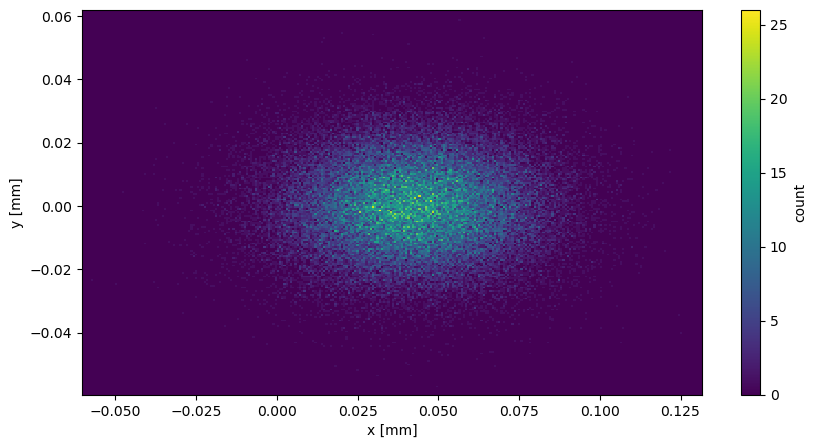

Sigma x at DVF: 20.97 μm
Sigma y at DVF: 12.04 μm


In [31]:
argmin = np.unravel_index(f8_dvf.argmin(), f8_dvf.shape)
# argmin

tx_s, ry_s = tx_vals[argmin], ry_vals[argmin]

cax.mirror.tx = tx_s
cax.mirror.ry = ry_s

display_image(cax.dvf_B1.image)
plt.show()

print(f"Sigma x at DVF: {cax.dvf_B1.image.sigma_h*1000:.2f} μm")
print(f"Sigma y at DVF: {cax.dvf_B1.image.sigma_v*1000:.2f} μm")

That doesn't look like it is optimized, the beam size is `21.76 μm` by `13.08 μm`.
But we must remember that the focus is actually behind the DVF by some 10 cm. 
Let's look at a caustic scan, check if the astigmatism is actually low and
evaluate the image at $f = (f_x + f_y)/2$:

Calculating caustic in parallel...
Caustic calculation completed.
-102.0408163265306 -102.0408163265306
Calculating caustic in parallel...
Caustic calculation completed.
-121.73778602350029 -83.35394763966191


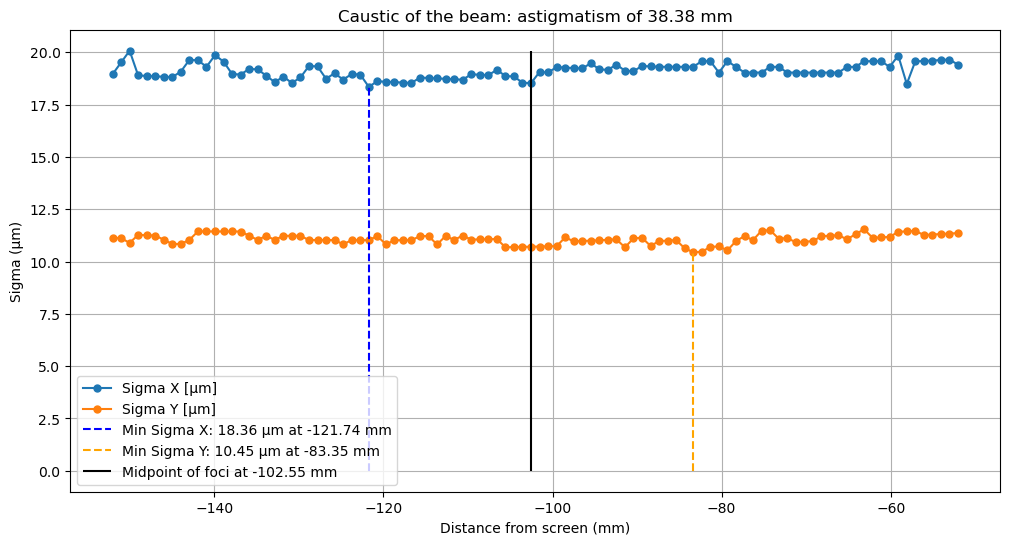

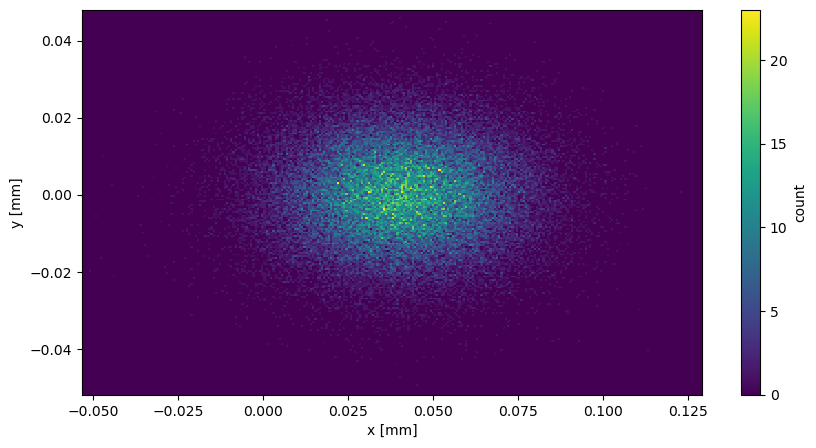

Sigma x at focus: 18.53 μm
Sigma y at focus: 10.71 μm


In [34]:
distances, fwhm_x, fwhm_y, fx, fy, f, astig, image = _astigmatism_acquisition(cax)



plt.figure(figsize=(12, 6))
plt.plot(distances, 1000*fwhm_x, marker='o', markersize=5, label="Sigma X [μm]")
plt.plot(distances, 1000*fwhm_y, marker='o', markersize=5, label="Sigma Y [μm]")
plt.vlines(fx, 0, 1000*np.nanmin(fwhm_x), color='blue', linestyle='--', label=f"Min Sigma X: {1000*np.nanmin(fwhm_x):.2f} μm at {distances[np.nanargmin(fwhm_x)]:.2f} mm")
plt.vlines(fy, 0, 1000*np.nanmin(fwhm_y), color='orange', linestyle='--', label=f"Min Sigma Y: {1000*np.nanmin(fwhm_y):.2f} μm at {distances[np.nanargmin(fwhm_y)]:.2f} mm")
plt.vlines(f, 0, 1000*np.nanmax(fwhm_x), color='black', linestyle='solid', label=f"Midpoint of foci at {f:.2f} mm")
plt.xlabel('Distance from screen (mm)')
plt.ylabel('Sigma (μm)')
plt.title(f'Caustic of the beam: astigmatism of {astig:.2f} mm')
plt.legend()
plt.grid()
plt.show()

display_image(image)
plt.show()

print(f"Sigma x at focus: {image.sigma_h*1000:.2f} μm")
print(f"Sigma y at focus: {image.sigma_v*1000:.2f} μm")

Now that looks like a proper minimum: the spatial sizes are `19.88 μm` by `11.37 μm` which are actually
in the range of the nominal values considering the associated uncertainty, namely:

- $\sigma_x = (19.9 \pm 0.2) ~\mu m$
- $\sigma_y = (11.5 \pm 1.2) ~\mu m$

An important question to answear is weather optimizing the beam with no astigmatism information
can actually match the foci as a result. This is useful as astigmatism acquisition is expensive and
may be prohibitive in the real beamline. For instance, $f_2(\sigma_x, \sigma_y)$ is a purely geometric
objective but the above grids show it's minimum as being on the edge of our sampled space. Let's 
compare the objective minimum and its value at the $TX^*$ and $RY^*$ positions obtained from the more
detailed $f_8$:

In [35]:
f2_argmin = np.argmin(f2_dvf)
f8_argmin = np.argmin(f8_dvf)
    
print(f"f2's range: ({np.min(f2_dvf):.2f} — {np.max(f2_dvf):.2f}) → {np.ptp(f2_dvf):.3f}")
print(f"Minimum of f2: {np.min(f2_dvf):.2f}")
print(f"f2 evaluated at f8's optimun location: {f2_dvf[argmin]:.2f}")
delt = f2_dvf[argmin] - np.min(f2_dvf)
print(f"Delta from the optimum: {delt:.2f} = {delt/np.ptp(f2_dvf)*100:.2f}% of full range")
print()
print(f"f8's range: ({np.min(f8_dvf):.2f} — {np.max(f8_dvf):.2f}) → {np.ptp(f8_dvf):.3f}")
print(f"Minimum of f8: {np.min(f8_dvf):.2f}")
print(f"f8 evaluated at f2's optimun location: {f8_dvf[np.unravel_index(f2_argmin, f2_dvf.shape)]:.2f}")
delt = f8_dvf[np.unravel_index(f2_argmin, f2_dvf.shape)] - np.min(f8_dvf)
print(f"Delta from the optimum: {delt:.2f} = {delt/np.ptp(f8_dvf)*100:.2f}% of full range")
print("\n Beam sizes at DVF position:")

print(f"\nAt f2's minimum: \n \t {df_at_dvf['sigma_x'][f2_argmin]*1000:.2f} μm X {df_at_dvf['sigma_y'][f2_argmin]*1000:.2f} μm")
print(f"At f8's minimum: \n \t {df_at_dvf['sigma_x'][f8_argmin]*1000:.2f} μm X {df_at_dvf['sigma_y'][f8_argmin]*1000:.2f} μm")

print("\n Beam sizes at focus position:")

print(f"\nAt f2's minimum: \n \t {df_at_focus['sigma_x'][f2_argmin]*1000:.2f} μm X {df_at_focus['sigma_y'][f2_argmin]*1000:.2f} μm")
print(f"At f8's minimum: \n \t {df_at_focus['sigma_x'][f8_argmin]*1000:.2f} μm X {df_at_focus['sigma_y'][f8_argmin]*1000:.2f} μm")


print(f"\n Astigmatism at f2's minimum: {df_at_dvf['astigmatism'][f2_argmin]:.2f} mm")

f2's range: (2.19 — 4.79) → 2.600
Minimum of f2: 2.19
f2 evaluated at f8's optimun location: 2.24
Delta from the optimum: 0.05 = 1.85% of full range

f8's range: (1.19 — 6.59) → 5.400
Minimum of f8: 1.19
f8 evaluated at f2's optimun location: 1.78
Delta from the optimum: 0.60 = 11.04% of full range

 Beam sizes at DVF position:

At f2's minimum: 
 	 23.53 μm X 11.56 μm
At f8's minimum: 
 	 21.74 μm X 13.14 μm

 Beam sizes at focus position:

At f2's minimum: 
 	 20.40 μm X 12.67 μm
At f8's minimum: 
 	 19.85 μm X 11.36 μm

 Astigmatism at f2's minimum: 202.72 mm


Unfortunatelly the pure geometric optimization doesn't match the foci automatically, yelding an 
astigmatism of ≈ 200 mm. We see a tradeoff between sigmas at the DVF position for $f_2$ and $f_8$ 
minima. At the focus the beam sizes are comparable, but the $f_8$ objective still wins.

Intensity information, although harder to define across simulation and real beamline, is still easily
obtainable without expensive scan procedures, let's now compare $f_8$ and $f_4$ minima:

In [36]:
f4_argmin = np.argmin(f4_dvf)
f8_argmin = np.argmin(f8_dvf)

print(f"f4's range: ({np.min(f4_dvf):.2f} — {np.max(f4_dvf):.2f}) → {np.ptp(f4_dvf):.3f}")
print(f"Minimum of f4: {np.min(f4_dvf):.2f}")
print(f"f4 evaluated at f8's optimun location: {f4_dvf[argmin]:.2f}")
delt = f4_dvf[argmin] - np.min(f4_dvf)
print(f"Delta from the optimum: {delt:.2f} = {delt/np.ptp(f4_dvf)*100:.2f}% of full range")
print()
print(f"f8's range: ({np.min(f8_dvf):.2f} — {np.max(f8_dvf):.2f}) → {np.ptp(f8_dvf):.3f}")
print(f"Minimum of f8: {np.min(f8_dvf):.2f}")
print(f"f8 evaluated at f4's optimun location: {f8_dvf[np.unravel_index(f4_argmin, f4_dvf.shape)]:.2f}")
delt = f8_dvf[np.unravel_index(f4_argmin, f4_dvf.shape)] - np.min(f8_dvf)
print(f"Delta from the optimum: {delt:.2f} = {delt/np.ptp(f8_dvf)*100:.2f}% of full range")


print("\n Beam sizes at DVF position:")

print(f"\nAt f4's minimum: \n \t {df_at_dvf['sigma_x'][f4_argmin]*1000:.2f} μm X {df_at_dvf['sigma_y'][f4_argmin]*1000:.2f} μm")
print(f"At f8's minimum: \n \t {df_at_dvf['sigma_x'][f8_argmin]*1000:.2f} μm X {df_at_dvf['sigma_y'][f8_argmin]*1000:.2f} μm")

print("\n Beam sizes at focus position:")

print(f"\nAt f4's minimum: \n \t {df_at_focus['sigma_x'][f4_argmin]*1000:.2f} μm X {df_at_focus['sigma_y'][f4_argmin]*1000:.2f} μm")
print(f"At f8's minimum: \n \t {df_at_focus['sigma_x'][f8_argmin]*1000:.2f} μm X {df_at_focus['sigma_y'][f8_argmin]*1000:.2f} μm")


print(f"\n Astigmatism at f4's minimum: {df_at_dvf['astigmatism'][f4_argmin]:.2f} mm")

f4's range: (1.17 — 4.40) → 3.230
Minimum of f4: 1.17
f4 evaluated at f8's optimun location: 1.18
Delta from the optimum: 0.01 = 0.41% of full range

f8's range: (1.19 — 6.59) → 5.400
Minimum of f8: 1.19
f8 evaluated at f4's optimun location: 1.30
Delta from the optimum: 0.11 = 2.02% of full range

 Beam sizes at DVF position:

At f4's minimum: 
 	 22.69 μm X 12.43 μm
At f8's minimum: 
 	 21.74 μm X 13.14 μm

 Beam sizes at focus position:

At f4's minimum: 
 	 19.92 μm X 11.52 μm
At f8's minimum: 
 	 19.85 μm X 11.36 μm

 Astigmatism at f4's minimum: 62.59 mm


This means that using $f_4$ is a good way of approaching a region not far from the more comprehensive
minimum while only capturing information at a fixed DVF position and only looking at beam data as
projected onto the DVF (beam size and intensity as defined above). This seems a reasonable approach
to online optimization of the CAX beamline. We actually get beam size `19.92 μm` by `11.52 μm` at 
focus position, which match the predicted values for beam size! It appears from the 
check we've just performed that optimizing the beam as seen on the DVF also results in an optimization 
of the beam at the focus position.

Now we will take a look at what happens if the acquisition is already taken in the focus position 
$\bar f$ as defined above. 

If we re-define our functionals to be measuring the observables at the focus position $\bar f$, we 
may expect to see a natural convergence of objectives: as focus matching occurs the size and intensity
measurements taken at $\bar f$ tend to naturally converge to their optimum values. Again, this kind 
of optimization procedure is, at the moment, impractical (or rather impossible!) to perform at the 
real beamline. 

In [37]:
n = 161

tx_vals = np.asarray(df_at_focus['TX']).reshape(n, n)
ry_vals = np.asarray(df_at_focus['RY']).reshape(n, n)

intensity_vals = np.asarray(df_at_focus['Intensity']).reshape(n, n)
sigmax_vals = np.asarray(df_at_focus['sigma_x']).reshape(n, n)
sigmay_vals = np.asarray(df_at_focus['sigma_y']).reshape(n, n)

astig_vals = np.asarray(df_at_focus['astigmatism']).reshape(n, n)

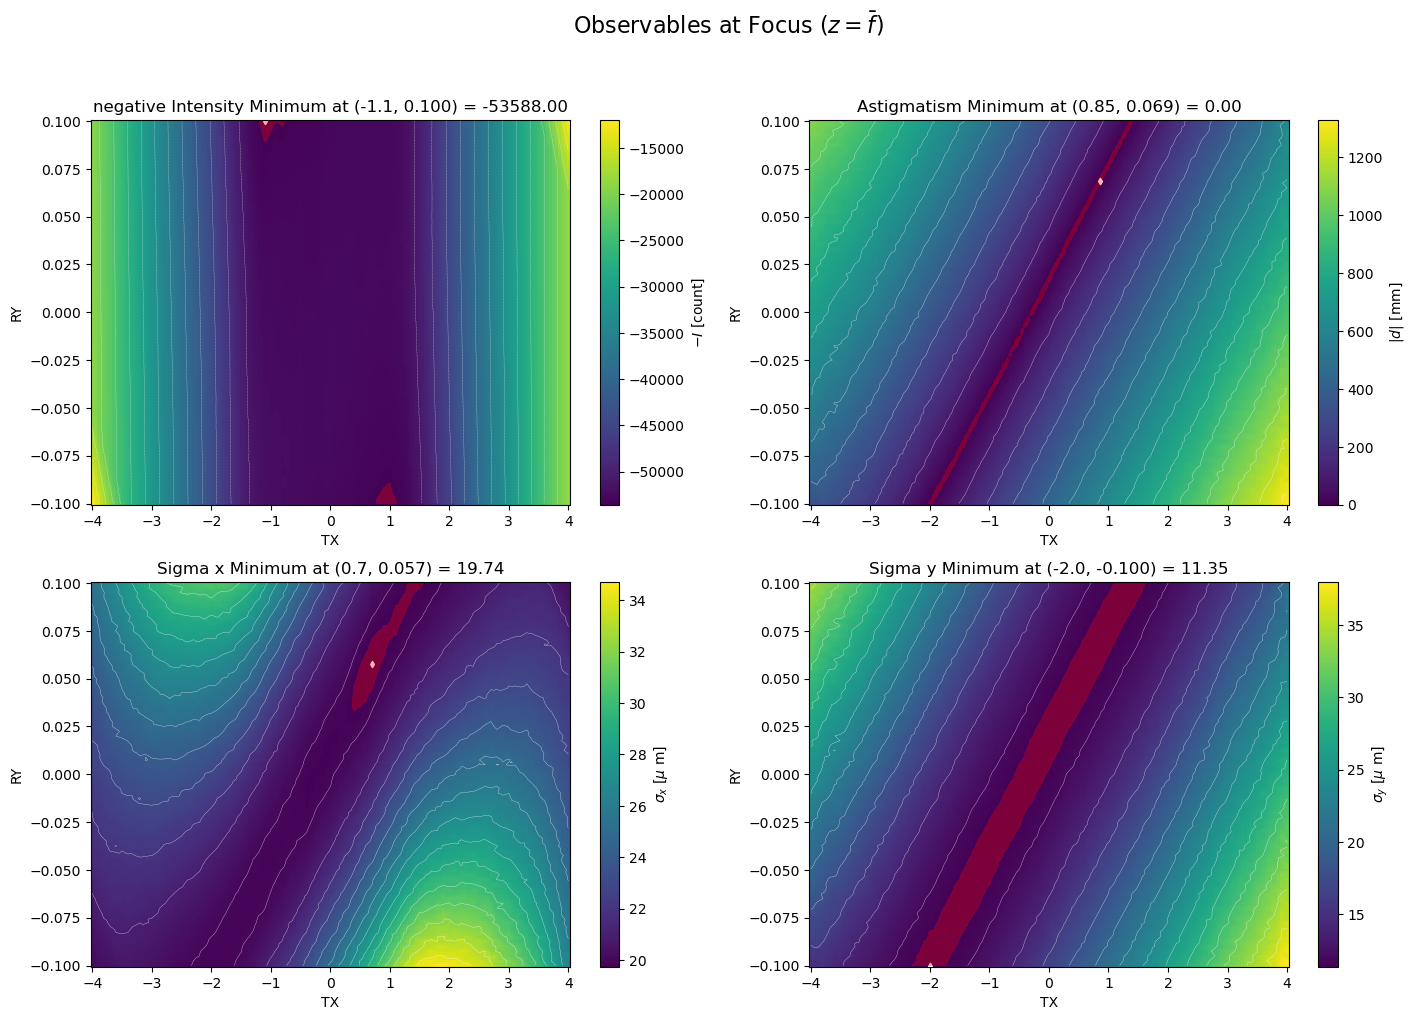

In [38]:
fig, axs = plt.subplots(2, 2, figsize=(17, 11))

axs = axs.flatten()

# title
fig.suptitle("Observables at Focus ($z=\\bar f$)", fontsize=16)

obs = [-intensity_vals, np.abs(astig_vals), 1000*sigmax_vals, 1000*sigmay_vals]
obs_lbl = ["$-I$ [count]", "$|d|$ [mm]", "$\\sigma_x$ [$\\mu$ m]", "$\\sigma_y$ [$\\mu$ m]"]
obs_names = ["negative Intensity", "Astigmatism", "Sigma x", "Sigma y"]

for i in range(4):

    p = axs[i].pcolormesh(tx_vals, ry_vals, obs[i], shading='auto')
    argmin = np.unravel_index(obs[i].argmin(), obs[i].shape)

    tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

    axs[i].scatter(tx_min, ry_min, c='white', marker='d',s=10)
    axs[i].contour(tx_vals, ry_vals, obs[i], levels=15, colors='white', linewidths=0.2)
    add_minimum_band_legend(axs[i], tx_vals, ry_vals, obs[i], legend=False)

    axs[i].set_xlabel("TX")
    axs[i].set_ylabel("RY")
    axs[i].set_title(obs_names[i] + 
                     f" Minimum at ({round(tx_min, 2)}, {ry_min:.3f}) = {obs[i][argmin]:.2f}")
    fig.colorbar(p, ax=axs[i], label=obs_lbl[i])



The behavior of observables is similar to the prior case, and astigmatism information is in fact the
exact same, as it is a global measure independent of DVF placement. Onwards to the normalized data:

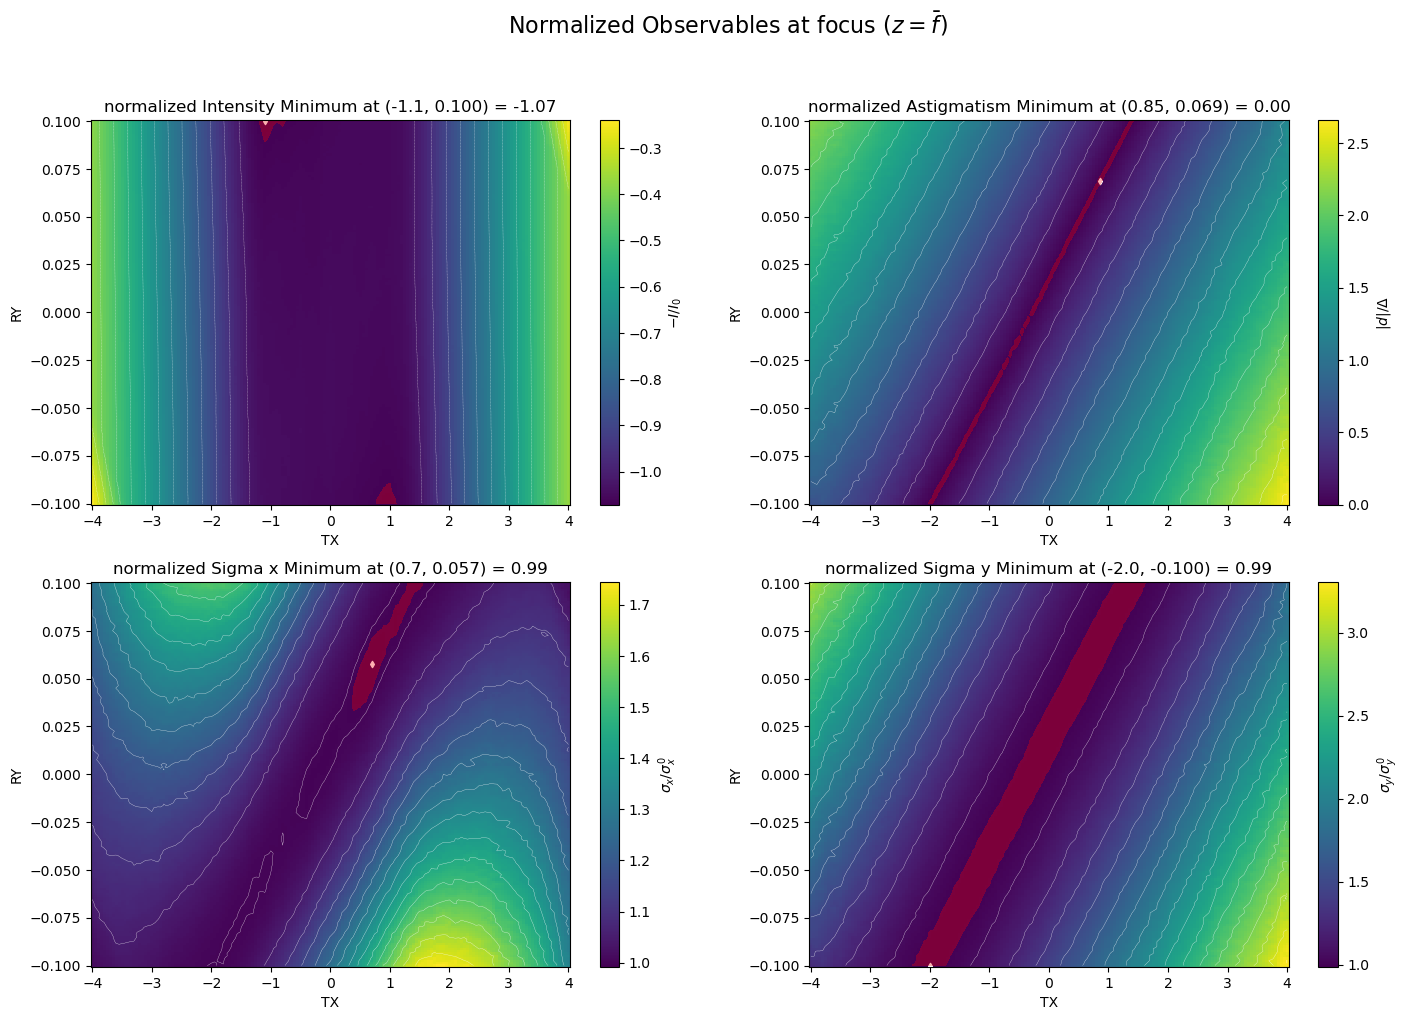

In [39]:
fig, axs = plt.subplots(2, 2, figsize=(17, 11))

axs = axs.flatten()

fig.suptitle("Normalized Observables at focus ($z=\\bar f$)", fontsize=16)


obs = [-intensity_vals/I0, np.abs(astig_vals)/Delta, 1000*sigmax_vals/sigmax_0, 1000*sigmay_vals/sigmay_0]
obs_lbl = ["$-I/I_0$", "$|d|/\\Delta$", "$\\sigma_x/\\sigma_x^0$", "$\\sigma_y/\\sigma_y^0$"]
obs_names = ["normalized Intensity", "normalized Astigmatism", "normalized Sigma x", "normalized Sigma y"]

for i in range(4):

    p = axs[i].pcolormesh(tx_vals, ry_vals, obs[i], shading='auto')
    argmin = np.unravel_index(obs[i].argmin(), obs[i].shape)

    tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

    axs[i].scatter(tx_min, ry_min, c='white', marker='d',s=10)
    axs[i].contour(tx_vals, ry_vals, obs[i], levels=15, colors='white', linewidths=0.2)

    add_minimum_band_legend(axs[i], tx_vals, ry_vals, obs[i], legend=False)

    axs[i].set_xlabel("TX")
    axs[i].set_ylabel("RY")
    axs[i].set_title(obs_names[i] + 
                     f" Minimum at ({round(tx_min, 2)}, {ry_min:.3f}) = {obs[i][argmin]:.2f}")
    fig.colorbar(p, ax=axs[i], label=obs_lbl[i])



Now we re-define the 8 objectives and plot them:

In [40]:
f1_focus = (1000)**2*sigmax_vals*sigmay_vals/intensity_vals
f2_focus = 1000*sigmax_vals/sigmax_0 + 1000*sigmay_vals/sigmay_0
f3_focus = -intensity_vals/I0
f4_focus = f2_focus + f3_focus
f5_focus = np.abs(astig_vals)/Delta
f6_focus = f2_focus + f5_focus
f7_focus = f3_focus + f5_focus
f8_focus = f4_focus + f5_focus

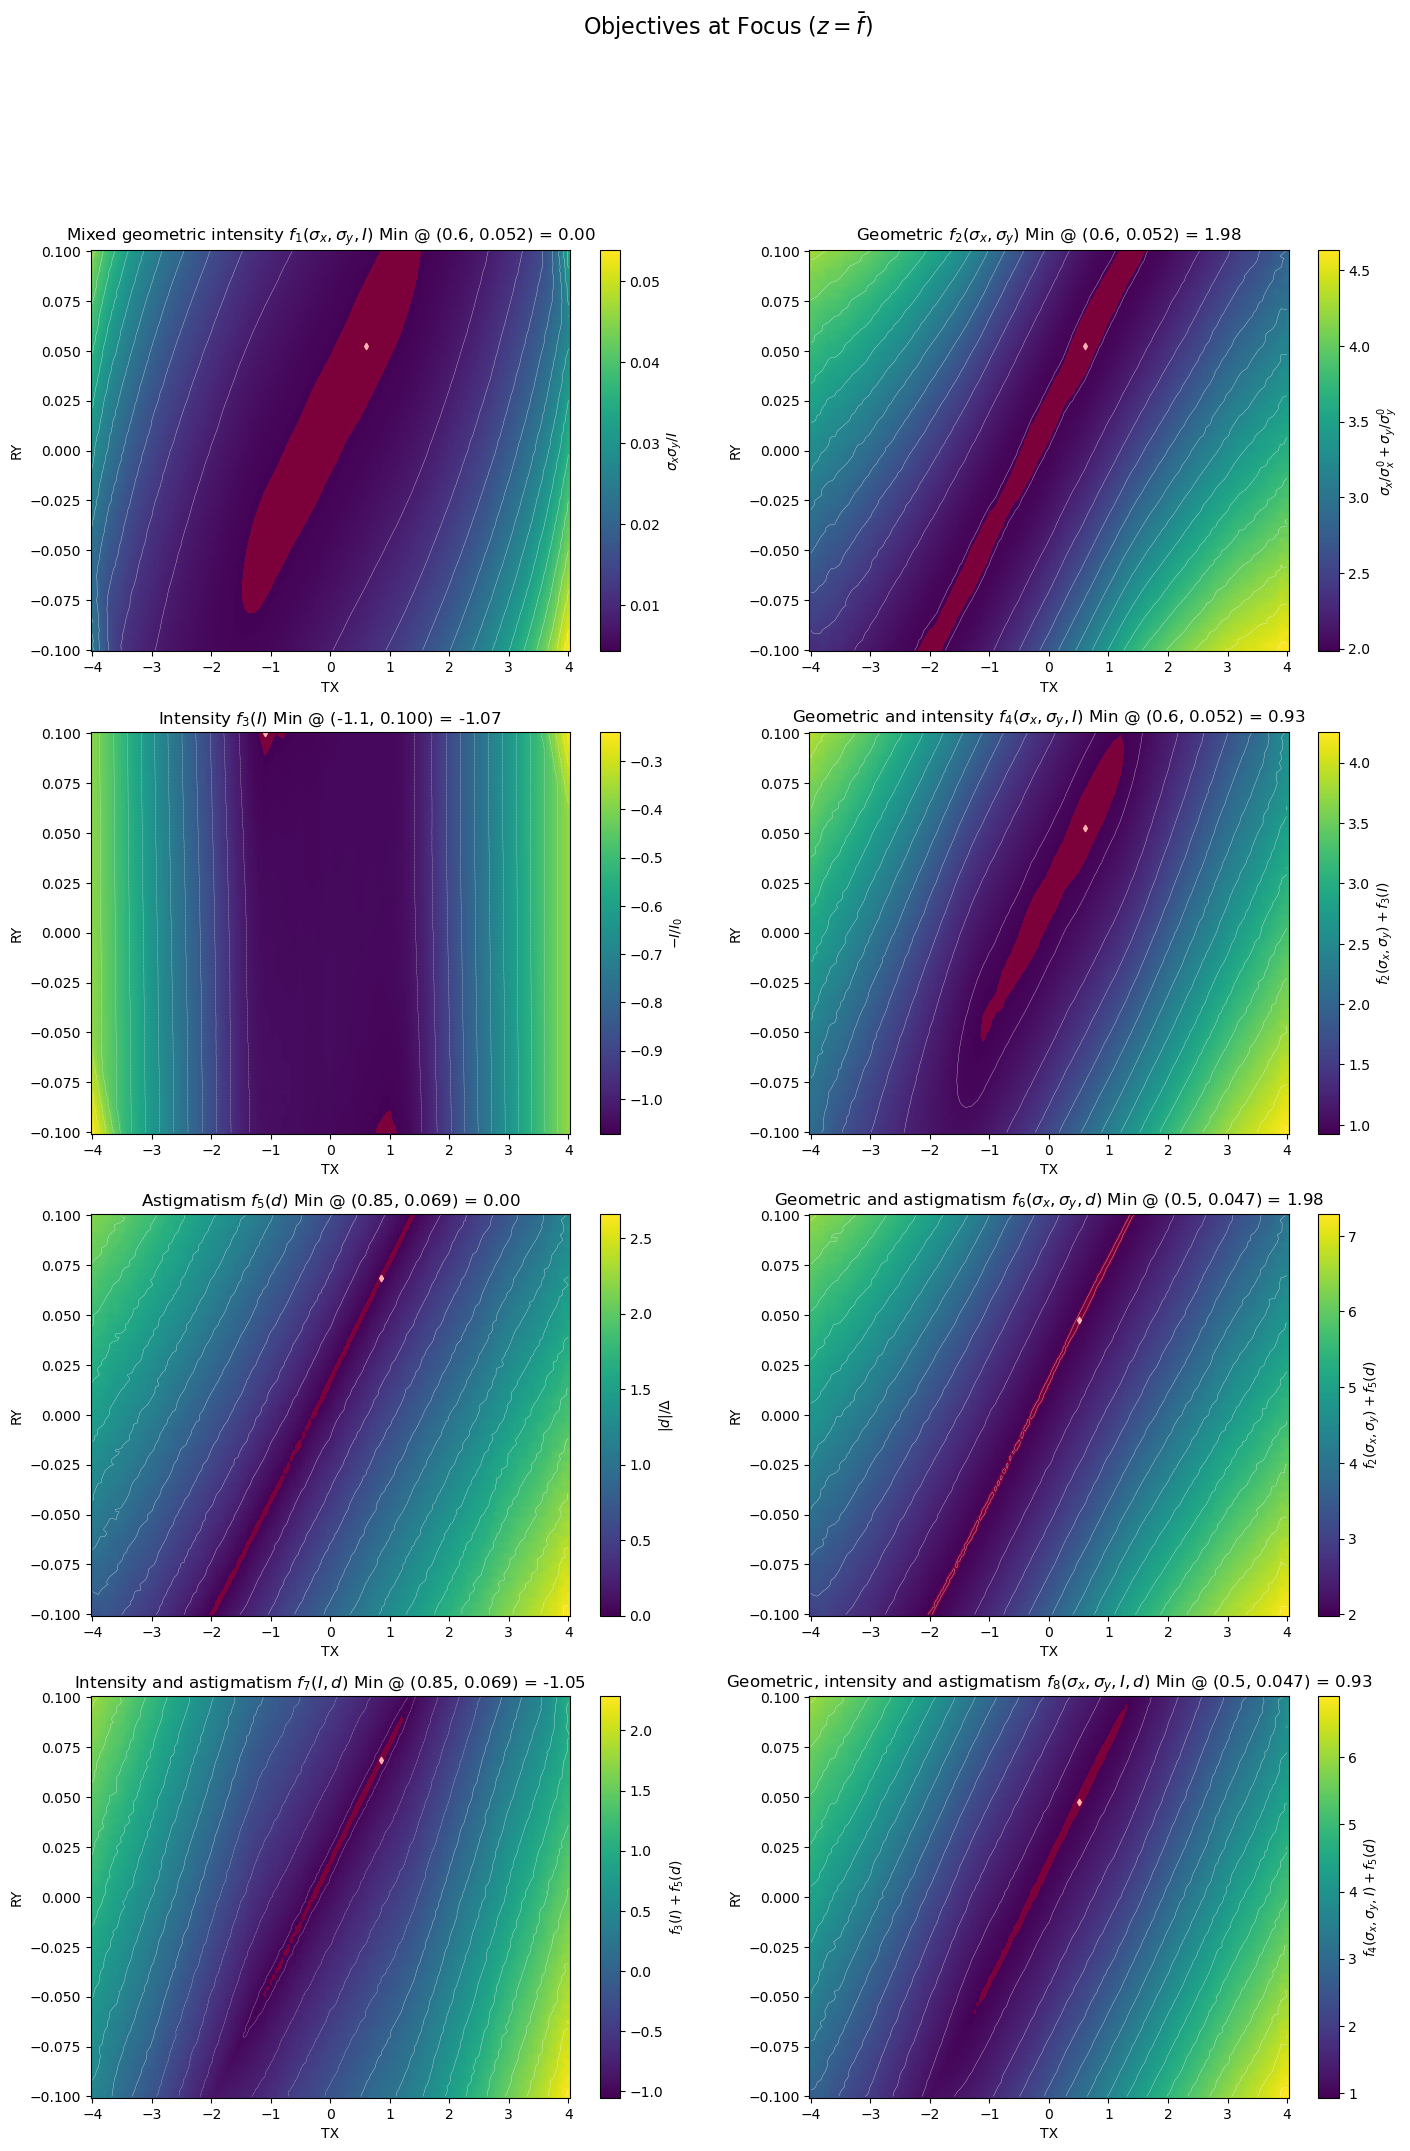

In [41]:
fig, axs = plt.subplots(4, 2, figsize=(17, 24))

axs = axs.flatten()

fig.suptitle("Objectives at Focus ($z=\\bar f$)", fontsize=16)

obs = [f1_focus, f2_focus, f3_focus, f4_focus, f5_focus, f6_focus, f7_focus, f8_focus]
obs_lbl = ["$\\sigma_x\\sigma_y/I$", 
           "$\\sigma_x/\\sigma_x^0 + \\sigma_y/\\sigma_y^0$", 
           "$-I/I_0$", 
           "$f_2(\\sigma_x, \\sigma_y) + f_3(I)$",
           "$|d|/\\Delta$",
           "$f_2(\\sigma_x, \\sigma_y) + f_5(d)$",
           "$f_3(I) + f_5(d)$",
           "$f_4(\\sigma_x, \\sigma_y, I) + f_5(d)$"]
obs_names = ["Mixed geometric intensity $f_1(\\sigma_x, \\sigma_y, I)$", 
             "Geometric $f_2(\\sigma_x, \\sigma_y)$", 
             "Intensity $f_3(I)$",
             "Geometric and intensity $f_4(\\sigma_x, \\sigma_y, I)$", 
             "Astigmatism $f_5(d)$",
             "Geometric and astigmatism $f_6(\\sigma_x, \\sigma_y, d)$",
             "Intensity and astigmatism $f_7(I, d)$",
             "Geometric, intensity and astigmatism $f_8(\\sigma_x, \\sigma_y, I, d)$"]

for i in range(8):

    p = axs[i].pcolormesh(tx_vals, ry_vals, obs[i], shading='auto')
    argmin = np.unravel_index(obs[i].argmin(), obs[i].shape)

    tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

    axs[i].scatter(tx_min, ry_min, c='white', marker='d',s=10)
    axs[i].contour(tx_vals, ry_vals, obs[i], levels=15, colors='white', linewidths=0.2)

    add_minimum_band_legend(axs[i], tx_vals, ry_vals, obs[i], legend=False)

    axs[i].set_xlabel("TX")
    axs[i].set_ylabel("RY")
    axs[i].set_title(obs_names[i] + 
                     f" Min @ ({round(tx_min, 2)}, {ry_min:.3f}) = {obs[i][argmin]:.2f}")
    fig.colorbar(p, ax=axs[i], label=obs_lbl[i])



An interesting hehaviour emerges: the geometric optimal location dominates the intensity optimal and
astigmatism optimal dominates all others, but these two distinct minima are very close. Let's compare
the beam sizes at the focus and DVF positions for these two conditions (i.e $f_4$ and $f_8$):

In [42]:
f4_argmin = np.argmin(f4_focus)
f8_argmin = np.argmin(f8_focus)

argmin = np.unravel_index(f8_focus.argmin(), f8_focus.shape)

print(f"f4's range: ({np.min(f4_focus):.2f} — {np.max(f4_focus):.2f}) → {np.ptp(f4_focus):.3f}")
print(f"Minimum of f4: {np.min(f4_focus):.2f}")
print(f"f4 evaluated at f8's optimun location: {f4_focus[argmin]:.2f}")
delt = f4_focus[argmin] - np.min(f4_focus)
print(f"Delta from the optimum: {delt:.2f} = {delt/np.ptp(f4_focus)*100:.2f}% of full range")
print()
print(f"f8's range: ({np.min(f8_focus):.2f} — {np.max(f8_focus):.2f}) → {np.ptp(f8_focus):.3f}")
print(f"Minimum of f8: {np.min(f8_focus):.2f}")
print(f"f8 evaluated at f4's optimun location: {f8_focus[np.unravel_index(f4_argmin, f4_focus.shape)]:.2f}")
delt = f8_focus[np.unravel_index(f4_argmin, f4_focus.shape)] - np.min(f8_focus)
print(f"Delta from the optimum: {delt:.2f} = {delt/np.ptp(f8_focus)*100:.2f}% of full range")


print("\n Beam sizes at DVF position:")

print(f"\nAt f4's minimum: \n \t {df_at_dvf['sigma_x'][f4_argmin]*1000:.2f} μm X {df_at_dvf['sigma_y'][f4_argmin]*1000:.2f} μm")
print(f"At f8's minimum: \n \t {df_at_dvf['sigma_x'][f8_argmin]*1000:.2f} μm X {df_at_dvf['sigma_y'][f8_argmin]*1000:.2f} μm")

print("\n Beam sizes at focus position:")

print(f"\nAt f4's minimum: \n \t {df_at_focus['sigma_x'][f4_argmin]*1000:.2f} μm X {df_at_focus['sigma_y'][f4_argmin]*1000:.2f} μm")
print(f"At f8's minimum: \n \t {df_at_focus['sigma_x'][f8_argmin]*1000:.2f} μm X {df_at_focus['sigma_y'][f8_argmin]*1000:.2f} μm")


print(f"\n Astigmatism at f4's minimum: {df_at_dvf['astigmatism'][f4_argmin]:.2f} mm")

f4's range: (0.93 — 4.26) → 3.327
Minimum of f4: 0.93
f4 evaluated at f8's optimun location: 0.93
Delta from the optimum: 0.00 = 0.01% of full range

f8's range: (0.93 — 6.91) → 5.986
Minimum of f8: 0.93
f8 evaluated at f4's optimun location: 0.94
Delta from the optimum: 0.01 = 0.13% of full range

 Beam sizes at DVF position:

At f4's minimum: 
 	 21.76 μm X 13.24 μm
At f8's minimum: 
 	 21.73 μm X 13.31 μm

 Beam sizes at focus position:

At f4's minimum: 
 	 19.75 μm X 11.37 μm
At f8's minimum: 
 	 19.76 μm X 11.37 μm

 Astigmatism at f4's minimum: 4.04 mm


As expected, since the information is already taken at the focus position, every observable converges
together to the true system minimum. The beam sizes at focus are `19.75 μm` by `11.37 μm` which are in
the range of expected values and of comparable size to the results obtained when fixing the DVF position.
The optimal points in knob-space are essentially the same, which is a solid indication of that particular
region being the global minimum of the system.

What can we conclude from this? Limiting ourselves to acquire data at $z=0$ and without DVF scans can 
lead to optimization the beam sizes at the focus position and can improve the foci matching, although
it isn't perfected. 

## RCDS optimizer application

The question now is weather the RCDS optimizer can find this minimum, as it took some good 9 hours
to construct the grid shown above. We will also try to optimize all 8 functions to see the optimizer's
performance. 

Again, the ideal case would be to find one of the minima revealed above with as little information as 
needed, ideally only moving the motors and recording beam properties as seen on the DVF (optimizing $f_4$).

In [43]:
from apsuite.optimization.rcds import RCDSParams, RCDS

Good, now we can define the functions to evaluate each observable independently and combine them to 
generate the 8 cost functions:

In [44]:
# Elementary acquisitions
def sigma_x_acq(image: Image):
    "Image sigma x in μm"
    return 1000*image.sigma_h

def sigma_y_acq(image: Image):
    "Image sigma y in μm"
    return 1000*image.sigma_v

def astigmatism_acq(cax: CAXSim):
    "Astigmatism acquisition"
    _, _, _, _, _, _, astig, _ = _astigmatism_acquisition(cax)

    return astig

In [45]:
# Separate objectives at DVF position
def f_1(cax: CAXSim):

    img = cax.dvf_B1.image

    return sigma_x_acq(img)*sigma_y_acq(img)/intensity(img)

def f_2(cax: CAXSim):

    img = cax.dvf_B1.image

    return sigma_x_acq(img)/sigmax_0 + sigma_y_acq(img)/sigmay_0

def f_3(cax: CAXSim):

    img = cax.dvf_B1.image

    return - intensity(img)/I0

def f_4(cax: CAXSim):

    return f_2(cax) + f_3(cax)

def f_5(cax: CAXSim):

    return np.abs(astigmatism_acq(cax))/Delta

def f_6(cax: CAXSim):

    return f_2(cax) + f_5(cax)

def f_7(cax: CAXSim):

    return f_3(cax) + f_5(cax)

def f_8(cax: CAXSim):

    return f_4(cax) + f_5(cax)
    

Let's define RCDS parameters and try to optimize $f_4$, changing the parameters to achieve convergence
with as few evaluations as possible:

In [46]:
params = RCDSParams()

In [47]:
# motor limits: TX and RY
params.limit_lower = [np.min(tx_vals), np.min(ry_vals)] # -4 mm and -0.1 mrad and -15cm
params.limit_upper = [np.max(tx_vals), np.max(ry_vals)] # 4 mm and 0.1 mrad and 15cm
params.caxsim = CAXSim()
# RCDS params
# these are the parameters RCDS requires for its internal
# logic and operations
params.max_number_evals = 500
params.max_number_iters = 6
params.initial_stepsize = 0.001
params.noise_level = 1e-3
params.tolerance = 1e-8
params.update_search_directions = True

# initial position refers to the initial point in the
# optimaztion variables space
# you could set it to a particular value or sample
# the available search space ramdomly, as below
params.initial_position = np.random.uniform(
    low=params.limit_lower, high=params.limit_upper)

# search directions along whith to start the line
# minimizations. It is a matrix with each row standing for a
# given direction

# initial directions are purely TX and RY
params.initial_search_directions = np.eye(2)

print(params)

 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Ca

In [48]:
class CAXRCDS(RCDS):

    def __init__(self, use_thread=True, isonline=True):
        super().__init__(use_thread=use_thread, isonline=isonline)
        self.params = params

    def objective_function(self, pos):

        tx, ry = pos
        caxsim = self.params.caxsim

        caxsim.mirror.tx = tx
        caxsim.mirror.ry = ry

        caxsim.trace()

        return f_4(caxsim)

In [49]:
opt = CAXRCDS()

In [ ]:
opt.start()

 Call to RESET
Traced through element 1: M1
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 2: DVF_A1
 Call to RESET
Traced through element 3: DVF_B1
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR


/opt/mamba_files/mamba/envs/sirius/lib/python3.9/site-packages/apsuite/optimization/rcds.py:542: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


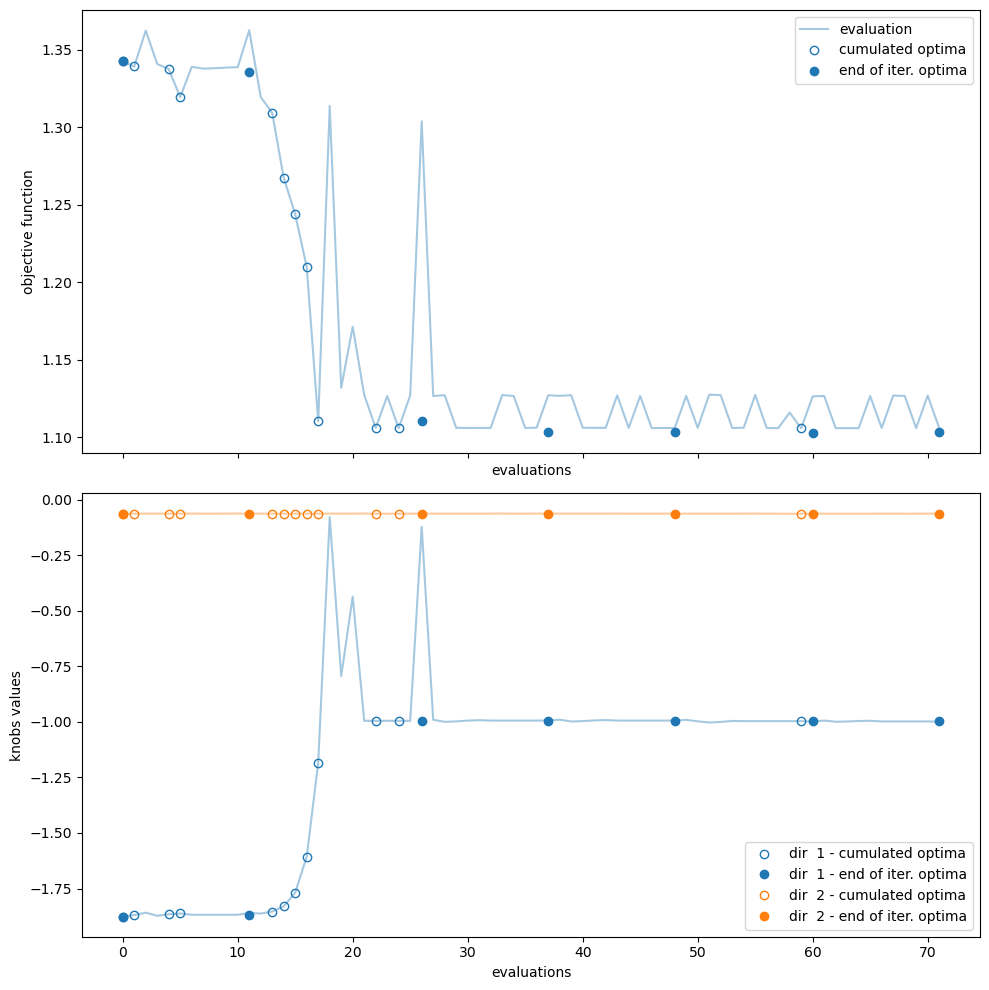

In [51]:
opt.plot_history()
plt.show()

In [52]:
print("Optimization Overview \n" + "="*50)

print(f"{'Evaluations':<20}: {opt.num_objective_evals}")
print()
print(f"{'Initial objective':<20}: {opt.objfuncs_evaluated[0]:.4f}")
print(f"{'Final objective':<20}: {opt.objfuncs_evaluated[-1]:.4f}")
print(f"{'f4 array minimum':<20}: {np.min(f4_dvf):.4f}")
print()
print(f"{'Initial position':<20}: {opt.positions_evaluated[0]}")
print(f"{'Final position':<20}: {opt.positions_evaluated[-1]}")
argmin = np.unravel_index(np.argmin(f4_dvf), f4_dvf.shape)
print(f"{'f4 position':<20}: [{tx_vals[argmin]:.8f} {ry_vals[argmin]:.8f}]")


Optimization Overview 
Evaluations         : 72

Initial objective   : 1.3426
Final objective     : 1.1060
f4 array minimum    : 1.1703

Initial position    : [-1.87597064 -0.06336896]
Final position      : [-0.9996291  -0.06361946]
f4 position         : [-0.30000000 -0.01750000]


Text(0, 0.5, 'RY')

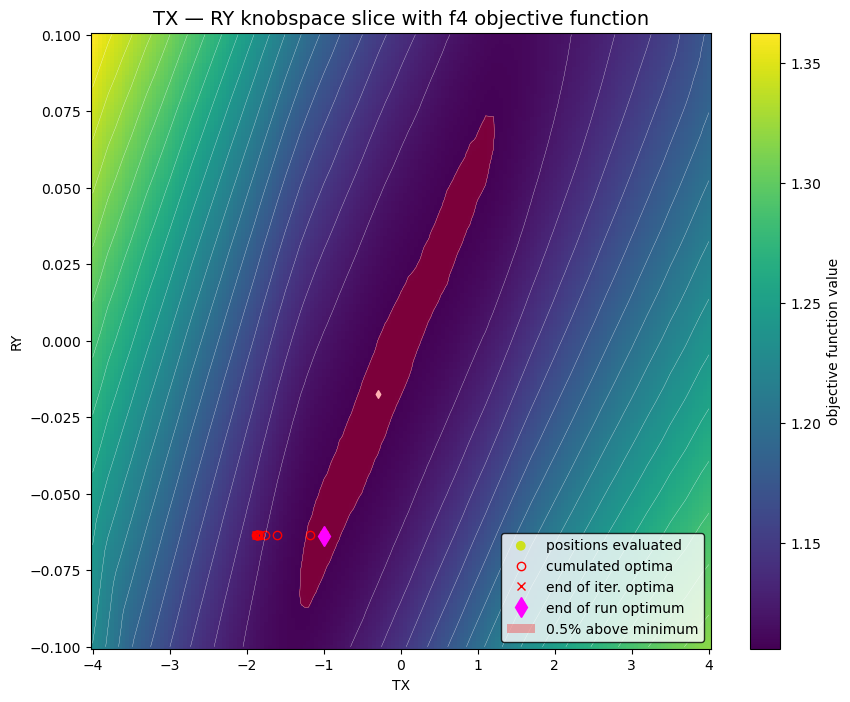

In [53]:
fig, ax = opt.plot_knobspace_slice(dir_idcs=(1, 2))
fig.set_size_inches(10, 8)
# 2. Create the X and Y grid coordinates

# Filled contour (the colormap background)
# filled_contour = ax.pcolormesh(TX, RY, f4_dvf, cmap='viridis')
p = ax.pcolormesh(tx_vals, ry_vals, f4_dvf, shading='auto')
argmin = np.unravel_index(f4_dvf.argmin(), f4_dvf.shape)

tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

ax.scatter(tx_min, ry_min, c='white', marker='d',s=15)

# Contour lines over the top (optional, for crisp boundaries)

# 0.5% above minimum filled contour
obj_amplitude = np.ptp(f4_dvf)
level = np.min(f4_dvf) + 0.005 * obj_amplitude
levels = np.linspace(level, np.max(f4_dvf), 20)
lines = ax.contour(tx_vals, ry_vals, f4_dvf, levels=levels, colors='white', linewidths=0.2)
add_minimum_band_legend(ax, tx_vals, ry_vals, f4_dvf, legend=True)

# Label the contour lines with their actual data values
# plt.clabel(lines, inline=True, fontsize=8)

# Add a colorbar legend
# plt.colorbar(filled_contour, label='Function Value Z')

# Formatting labels
plt.title('TX — RY knobspace slice with f4 objective function', fontsize=14)
plt.xlabel('TX')
plt.ylabel('RY')

# fig


In [ ]:
fig, ax = opt.plot_knobspace_slice(dir_idcs=(1, 2))
fig.set_size_inches(10, 8)
# 2. Create the X and Y grid coordinates

# Filled contour (the colormap background)
filled_contour = ax.pcolormesh(TX, RY, f8_dvf, cmap='viridis')
p = ax.pcolormesh(tx_vals, ry_vals, f8_dvf, shading='auto')
argmin = np.unravel_index(f8_dvf.argmin(), f8_dvf.shape)

tx_min, ry_min = tx_vals[argmin], ry_vals[argmin]

diamond = ax.scatter(tx_min, ry_min, c='white', marker='d',s=15, label='sampled minimum')

# Contour lines over the top (optional, for crisp boundaries)

# 0.5% above minimum filled contour
obj_amplitude = np.ptp(f8_dvf)
level = np.min(f8_dvf) + 0.005 * obj_amplitude
levels = np.linspace(level, np.max(f8_dvf), 20)
lines = ax.contour(tx_vals, ry_vals, f8_dvf, levels=levels, colors='white', linewidths=0.2)
add_minimum_band_legend(ax, tx_vals, ry_vals, f8_dvf, legend=True)


ax.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='black')
# Label the contour lines with their actual data values
# plt.clabel(lines, inline=True, fontsize=8)
proxy = plt.Rectangle((0,0),1,1,fc = cf.collections[0].get_facecolor()[0], label='0.5% above minimum')
# Add a colorbar legend
# plt.colorbar(filled_contour, label='Function Value Z')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles+[proxy], loc='lower right', fontsize=10, frameon=True, edgecolor='black')
# Formatting labels
# plt.title('2D Function Contour and Colormap')
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# fig


⚠️ As mentioned, by switching the analysis method (currently getting the raw data from `Shadow`), the 
simulation results are underestimating beam sizes, which explains the facth that the optimizer can reach
a final objective *lower* than the minima we found from the grid data.

This means the optimizer's performance is artifiically enhanced in the results presented here. In any case,
the conclusion at this point is that the optimizer parameters used here are enough to always reach the 0.5%
margin above the minimum consistently, it now remains to re-introduce the better analysis methods and 
validate these conclusions once again.